In [20]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import os, random, sys
import numpy as np
import pandas as pd
import xarray as xr
import tensorflow as tf
import keras
# import keras.ops as ops
# import keras.random as krandom
from tensorflow.keras import backend as K
from keras.layers import Lambda, Input, Dense, Reshape, Layer
from keras.models import Model
from keras.losses import mean_squared_error as mse
from keras.metrics import categorical_crossentropy

# Ensure local modules are findable
sys.path.append(os.getcwd())

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.cluster import KMeans

import clustering_functions as cf
import skill_functions as sf
import preprocessing_functions as pf

# Global Constants
g0                         = 9.80665
djf_months                 = [12, 1, 2]
RANDOM_STATE               = 42
HOLDOUT_FRAC               = 0.30

# Architecture
cluster_number             = 4
pr_cluster_number          = 4
original_dim               = 825
latent_dim                 = 15
dim_layer1, dim_layer2, dim_layer3 = 256, 128, 64
activation_function        = 'relu'
batch_size                 = 128
epochs                     = 100
n_splits                   = 5
reconstruction_loss_factor = 0.5

input_shape                = (original_dim,)
input_shape_r              = (pr_cluster_number,)
filepath                   = "results/standard_vae_djf/"

def set_seed(seed=42):
    import random, os, numpy as np, tensorflow as tf
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.keras.utils.set_random_seed(seed)

def sampling(args):
    z_mean, z_log_sigma = args
    batch = K.shape(z_mean)[0]
    dim = K.shape(z_mean)[1]
    epsilon = K.random_normal(shape=(batch, dim))
    return z_mean + K.exp(0.5 * z_log_sigma) * epsilon

set_seed(RANDOM_STATE)
os.makedirs(filepath, exist_ok=True)
print(f"Parameters, Imports, and Sampling Loaded. Results saved to: {filepath}")

Parameters, Imports, and Sampling Loaded. Results saved to: results/standard_vae_djf/


In [21]:
z500 = pf.preprocess_dataset(
    filename              = '../data.nosync/era5_z500_daily_250_atlantic_1940_2022.nc',
    variable_name         = 'z',
    multiplication_factor = 1 / g0,
    geographical_filter   = 'new atlantic',
    months_filter         = djf_months,
    anomalies             = True,
    normalization         = False,
    rolling_window        = 5)

z500 = z500.where(z500['time.year'] > 1978, drop=True)
z500 = z500.where(z500['time.year'] < 2021, drop=True)

weights = np.cos(np.deg2rad(z500.latitude))
z500    = z500 * weights
z500    = z500 / z500.std()

print(f"Z500 DJF shape: {z500.shape}")


Z500 DJF shape: (3791, 25, 33)


In [22]:
pr_spatial = xr.open_dataset('../data.nosync/MSWEP_pr_total_DJF.nc')['precipitation']
pr_spatial = pr_spatial.where(pr_spatial['time.year'] < 2021, drop=True)

print(f"pr_spatial shape: {pr_spatial.shape}")
assert z500.shape[0] == pr_spatial.shape[0], "Time mismatch!"
print("Time alignment OK.")


pr_spatial shape: (3791, 150, 160)
Time alignment OK.


In [23]:
times = pd.to_datetime(z500.time.values)
winter_year = np.array([t.year if t.month == 12 else t.year - 1 for t in times])

X = cf.reshape_data_for_clustering(z500)

gss = GroupShuffleSplit(n_splits=1, test_size=HOLDOUT_FRAC, random_state=RANDOM_STATE)
train_idx, holdout_idx = next(gss.split(X, groups=winter_year))

train_winters   = sorted(set(winter_year[train_idx].tolist()))
holdout_winters = sorted(set(winter_year[holdout_idx].tolist()))
overlap = set(train_winters) & set(holdout_winters)

print(f"Total days    : {len(X)}")
print(f"Training days : {len(train_idx)}  ({len(train_winters)} winters)")
print(f"Holdout  days : {len(holdout_idx)}  ({len(holdout_winters)} winters)")
print(f"Winter overlap: {len(overlap)}  {'<- LEAKAGE!' if overlap else '<- CLEAN'}")

X_train   = X[train_idx]
X_holdout = X[holdout_idx]


Total days    : 3791
Training days : 2619  (30 winters)
Holdout  days : 1172  (13 winters)
Winter overlap: 0  <- CLEAN


In [24]:
pr_values = pr_spatial.values
nt, ny, nx = pr_values.shape
pr_flat = np.reshape(pr_values, [nt, ny * nx], order='F')

pr_flat_train   = pr_flat[train_idx]
pr_flat_holdout = pr_flat[holdout_idx]

print(f"Fitting KMeans (k={pr_cluster_number}) on {len(train_idx)} training days...")
kmeans_pr = KMeans(n_clusters=pr_cluster_number, n_init=10, random_state=RANDOM_STATE)
kmeans_pr.fit(pr_flat_train)

pr_labels_train   = kmeans_pr.predict(pr_flat_train)
pr_labels_holdout = kmeans_pr.predict(pr_flat_holdout)

print("Training label dist: " +
      "  ".join([f"c{k}={np.sum(pr_labels_train==k)}" for k in range(pr_cluster_number)]))
print("Holdout  label dist: " +
      "  ".join([f"c{k}={np.sum(pr_labels_holdout==k)}" for k in range(pr_cluster_number)]))


Fitting KMeans (k=4) on 2619 training days...
Training label dist: c0=1850  c1=493  c2=167  c3=109
Holdout  label dist: c0=781  c1=268  c2=68  c3=55


In [25]:
q95_threshold = np.percentile(pr_flat_train, 95, axis=0)

exceed_train   = (pr_flat_train   >= q95_threshold).astype(np.float32)
exceed_holdout = (pr_flat_holdout >= q95_threshold).astype(np.float32)
exceed_all     = (pr_flat         >= q95_threshold).astype(np.float32)

def flat_to_xarray(flat_exceed, time_coords, pr_ref):
    data_3d = np.reshape(flat_exceed, [len(time_coords), ny, nx], order='F')
    return xr.DataArray(
        data_3d,
        coords={'time': time_coords,
                'latitude':  pr_ref.latitude.values,
                'longitude': pr_ref.longitude.values},
        dims=['time', 'latitude', 'longitude'],
        name='precipitation')

threshold_qn95_train   = flat_to_xarray(exceed_train,   pr_spatial.time[train_idx],   pr_spatial)
threshold_qn95_holdout = flat_to_xarray(exceed_holdout, pr_spatial.time[holdout_idx], pr_spatial)
threshold_qn95_all     = flat_to_xarray(exceed_all,     pr_spatial.time,              pr_spatial)

print(f"Q95 threshold computed. Fraction exceeding: {exceed_train.mean():.3f} (expect ~0.05)")


Q95 threshold computed. Fraction exceeding: 0.051 (expect ~0.05)


In [26]:
# Standard VAE - no conditioning, no r branch, no dummy input
input_shape = (original_dim,)

inputs_x = Input(shape=input_shape, name='encoder_input')
x       = Dense(dim_layer1, activation=activation_function)(inputs_x)
x       = Dense(dim_layer2, activation=activation_function)(x)
x       = Dense(dim_layer3, activation=activation_function)(x)

z_mean    = Dense(latent_dim, name='z_mean')(x)
z_log_var = Dense(latent_dim, name='z_log_var')(x)

z = Lambda(sampling, output_shape=(latent_dim,), name='z')([z_mean, z_log_var])

encoder = Model(inputs_x, [z_mean, z_log_var, z], name='encoder')
encoder.summary()

latent_inputs = Input(shape=(latent_dim,), name='z_sampling')
dec1    = Dense(dim_layer3, activation=activation_function)(latent_inputs)
dec2    = Dense(dim_layer2, activation=activation_function)(dec1)
dec3    = Dense(dim_layer1, activation=activation_function)(dec2)
outputs = Dense(original_dim)(dec3)

decoder = Model(latent_inputs, outputs, name='decoder')

from keras.layers import Layer
class VAELossLayer(Layer):
    def __init__(self, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)

    def call(self, inputs):
        inputs_x, outputs_vae, z_mean, z_log_var = inputs
        recon_loss = K.mean(mse(inputs_x, outputs_vae)) * original_dim * reconstruction_loss_factor
        kl_loss = K.mean(-0.5 * K.sum(1 + z_log_var - K.square(z_mean) - K.exp(z_log_var), axis=-1))
        self.add_loss(recon_loss + kl_loss)
        return outputs_vae

vae_output = decoder(encoder(inputs_x)[2])
loss_out = VAELossLayer()([inputs_x, vae_output, z_mean, z_log_var])
vae = Model(inputs_x, loss_out, name='standard_vae')

vae.compile(optimizer='adam')
vae.summary()

vae.save_weights(filepath + f'random_weights_{cluster_number}.h5')
print("Model compiled with Custom Loss Layer. Random weights saved.")

Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 encoder_input (InputLayer)  [(None, 825)]                0         []                            
                                                                                                  
 dense_7 (Dense)             (None, 256)                  211456    ['encoder_input[0][0]']       
                                                                                                  
 dense_8 (Dense)             (None, 128)                  32896     ['dense_7[0][0]']             
                                                                                                  
 dense_9 (Dense)             (None, 64)                   8256      ['dense_8[0][0]']             
                                                                                            

In [27]:
# ================================================================
# 5-Fold GroupKFold Training -- BEST-FOLD SELECTION + OOF COLLECTION
# Identical strategy to cmmvae_mswep_djf_winter_groups.ipynb:
#   - Each fold trains from the same random starting weights
#   - Best fold = lowest final val_loss
#   - out_of_fold_z_mean: each training day encoded by the one fold
#     that NEVER trained on it (leakage-free CV latent space)
# ================================================================
gkf = GroupKFold(n_splits=n_splits)
winter_year_train = winter_year[train_idx]

fold_histories     = []
out_of_fold_z_mean = np.zeros((len(X_train), latent_dim), dtype=np.float32)
best_val_loss      = float('inf')
best_fold          = -1

for fold, (cv_tr_idx, cv_val_idx) in enumerate(
        gkf.split(X_train, groups=winter_year_train)):

    print(f"\n--- FOLD {fold + 1}/{n_splits} ---")
    X_cv_tr  = X_train[cv_tr_idx]
    X_cv_val = X_train[cv_val_idx]

    cv_tr_winters  = sorted(set(winter_year_train[cv_tr_idx].tolist()))
    cv_val_winters = sorted(set(winter_year_train[cv_val_idx].tolist()))
    print(f"  CV-train winters : {cv_tr_winters}")
    print(f"  CV-val   winters : {cv_val_winters}")

    # Reset to same random starting point every fold
    vae.load_weights(filepath + f'random_weights_{cluster_number}.h5')

    history = vae.fit(
        X_cv_tr, X_cv_tr,
        epochs          = epochs,
        batch_size      = batch_size,
        validation_data = (X_cv_val, X_cv_val),
        verbose         = 0)

    fold_histories.append(history.history)
    val_loss = history.history['val_loss'][-1]
    print(f"  Fold {fold + 1} val_loss = {val_loss:.4f}")

    vae.save_weights(filepath + f'weights_{cluster_number}_fold{fold + 1}.h5')

    # OUT-OF-FOLD: encode validation days with the model that never saw them
    z_mean_val, _, _ = encoder.predict(X_cv_val, batch_size=batch_size, verbose=0)
    out_of_fold_z_mean[cv_val_idx] = z_mean_val

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_fold     = fold + 1

print(f"\nBest fold: {best_fold}  |  val_loss = {best_val_loss:.4f}")
vae.load_weights(filepath + f'weights_{cluster_number}_fold{best_fold}.h5')
vae.save_weights(filepath + f'final_weights_{cluster_number}.h5')
print("Best fold weights loaded and saved as final_weights.")
print(f"out_of_fold_z_mean shape: {out_of_fold_z_mean.shape}")



--- FOLD 1/5 ---
  CV-train winters : [1978, 1979, 1980, 1983, 1985, 1987, 1989, 1992, 1993, 1994, 1996, 1997, 1999, 2000, 2001, 2004, 2007, 2008, 2010, 2011, 2013, 2016, 2019, 2020]
  CV-val   winters : [1988, 1991, 1995, 1998, 2006, 2018]
  Fold 1 val_loss = 57.9695

--- FOLD 2/5 ---
  CV-train winters : [1978, 1979, 1985, 1987, 1988, 1991, 1992, 1993, 1994, 1995, 1997, 1998, 2000, 2001, 2004, 2006, 2007, 2010, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters : [1980, 1983, 1989, 1996, 1999, 2008]
  Fold 2 val_loss = 59.6520

--- FOLD 3/5 ---
  CV-train winters : [1980, 1983, 1985, 1988, 1989, 1991, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2001, 2004, 2006, 2007, 2008, 2011, 2013, 2016, 2018, 2019, 2020]
  CV-val   winters : [1978, 1979, 1987, 1992, 2000, 2010]
  Fold 3 val_loss = 65.6251

--- FOLD 4/5 ---
  CV-train winters : [1978, 1979, 1980, 1983, 1985, 1987, 1988, 1989, 1991, 1992, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2004, 2006, 2007, 2008, 2010, 2016, 2018]
  CV-v

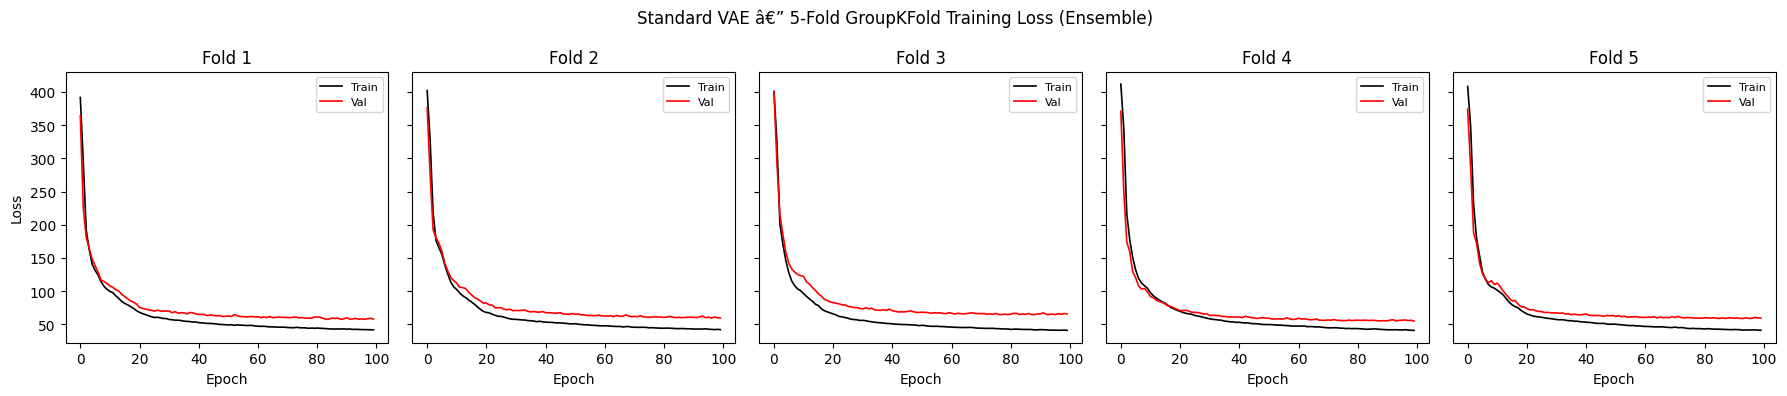

In [28]:
fig, axes = plt.subplots(1, n_splits, figsize=(18, 4), sharey=True)
for i, hist in enumerate(fold_histories):
    axes[i].plot(hist['loss'],     label='Train', color='black', linewidth=1.2)
    axes[i].plot(hist['val_loss'], label='Val',   color='red',   linewidth=1.2)
    axes[i].set_title(f'Fold {i + 1}')
    axes[i].set_xlabel('Epoch')
    if i == 0: axes[i].set_ylabel('Loss')
    axes[i].legend(fontsize=8)
plt.suptitle('Standard VAE â€” 5-Fold GroupKFold Training Loss (Ensemble)', fontsize=12)
plt.tight_layout()
plt.savefig(filepath + 'kfold_loss_curves.png', dpi=150)
plt.show()


In [29]:
# Encode full dataset with best fold weights (single consistent latent space)
print(f"Encoding full dataset with best fold {best_fold} weights...")
z_mean_all, _, _ = encoder.predict(X, batch_size=batch_size, verbose=0)

z_mean_train   = z_mean_all[train_idx]
z_mean_holdout = z_mean_all[holdout_idx]
print(f"z_mean_train   shape: {z_mean_train.shape}")
print(f"z_mean_holdout shape: {z_mean_holdout.shape}")
print("Single latent space from best fold -- no ensemble averaging.")


Encoding full dataset with best fold 4 weights...
z_mean_train   shape: (2619, 15)
z_mean_holdout shape: (1172, 15)
Single latent space from best fold -- no ensemble averaging.


In [30]:
# KMeans on ensemble latent space (training data only — leakage-free)
print(f"Fitting KMeans (k={cluster_number}) on training latent space...")
kmeans_latent = KMeans(n_clusters=cluster_number, n_init=20, random_state=RANDOM_STATE)
kmeans_latent.fit(z_mean_train)

c_train   = kmeans_latent.predict(z_mean_train)
c_holdout = kmeans_latent.predict(z_mean_holdout)
c_all     = kmeans_latent.predict(z_mean_ensemble)  # for visualisation only

def soft_probs_from_kmeans(km, z):
    distances = km.transform(z)
    neg_dist  = -distances
    neg_dist -= neg_dist.max(axis=1, keepdims=True)
    exp_d     = np.exp(neg_dist)
    return exp_d / exp_d.sum(axis=1, keepdims=True)

soft_train   = soft_probs_from_kmeans(kmeans_latent, z_mean_train)
soft_holdout = soft_probs_from_kmeans(kmeans_latent, z_mean_holdout)
# Out-of-fold soft probs: each training day predicted by the fold that NEVER trained on it
soft_oof     = soft_probs_from_kmeans(kmeans_latent, out_of_fold_z_mean)

print("Training cluster distribution:")
for k in range(cluster_number):
    n = (c_train == k).sum()
    print(f"  Cluster {k}: {n} days  ({100*n/len(c_train):.1f}%)")


Fitting KMeans (k=4) on training latent space...
Training cluster distribution:
  Cluster 0: 699 days  (26.7%)
  Cluster 1: 766 days  (29.2%)
  Cluster 2: 454 days  (17.3%)
  Cluster 3: 700 days  (26.7%)


In [31]:
# Align latent clusters: Wettest -> Driest (training data only — leakage-free)
precip_per_cluster = []
for k in range(cluster_number):
    idx_k = np.where(c_train == k)[0]
    total = np.sum(pr_flat_train[idx_k, :]) if len(idx_k) > 0 else 0.0
    precip_per_cluster.append(total)

order   = np.argsort(precip_per_cluster)[::-1]
inv_map = {old: new for new, old in enumerate(order)}

# Aligned labels for train, holdout, and ALL data
c_train_aligned   = np.array([inv_map[k] for k in c_train])
c_holdout_aligned = np.array([inv_map[k] for k in c_holdout])
c_all_aligned     = np.array([inv_map[k] for k in c_all])

soft_train_aligned   = soft_train[:,   order]
soft_holdout_aligned = soft_holdout[:, order]
soft_oof_aligned     = soft_oof[:,     order]   # <- CV (out-of-fold), leakage-free

# labels_reordered = ALL days — used for cluster centre maps & full-period odds ratio
labels_reordered         = c_all_aligned.astype(float)
labels_holdout_reordered = c_holdout_aligned.astype(float)

print("Regime order (wettest first):", order)
print("Aligned training distribution:")
for k in range(cluster_number):
    n = (c_train_aligned == k).sum()
    print(f"  Regime {k+1}: {n} days  ({100*n/len(c_train_aligned):.1f}%)")
print("\nAligned holdout distribution:")
for k in range(cluster_number):
    n = (c_holdout_aligned == k).sum()
    print(f"  Regime {k+1}: {n} days  ({100*n/len(c_holdout_aligned):.1f}%)")


Regime order (wettest first): [2 0 1 3]
Aligned training distribution:
  Regime 1: 454 days  (17.3%)
  Regime 2: 699 days  (26.7%)
  Regime 3: 766 days  (29.2%)
  Regime 4: 700 days  (26.7%)

Aligned holdout distribution:
  Regime 1: 275 days  (23.5%)
  Regime 2: 301 days  (25.7%)
  Regime 3: 307 days  (26.2%)
  Regime 4: 289 days  (24.7%)


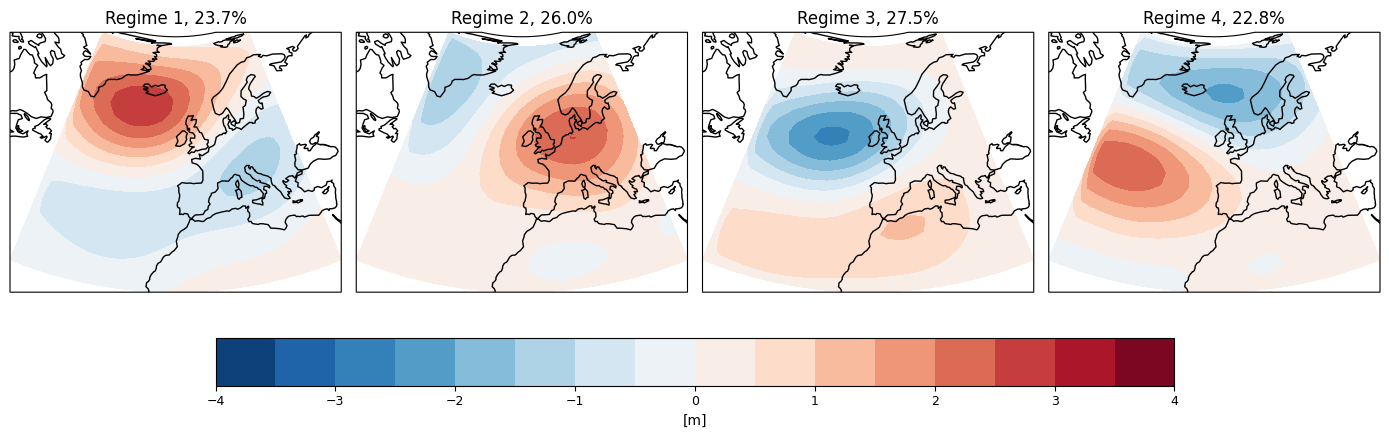

In [32]:
regime_names = [f'Regime {i+1}' for i in range(cluster_number)]

z500_lab = z500.assign_coords(label=('time', labels_reordered)) / weights
means    = z500_lab.groupby('label').mean()

cf.visualise_contourplot(
    cluster_centers = means,
    unit            = '[m]',
    regime_names    = regime_names,
    vmin=-4, vmax=4.5, steps=0.5,
    color_scheme    = 'RdBu_r',
    labels_data     = X,
    labels          = labels_reordered,
    borders         = False,
    col_number      = cluster_number,
    projection      = ccrs.AlbersEqualArea(central_longitude=-10, central_latitude=50))

plt.savefig(filepath + 'cluster_centers.png', dpi=150)
plt.show()


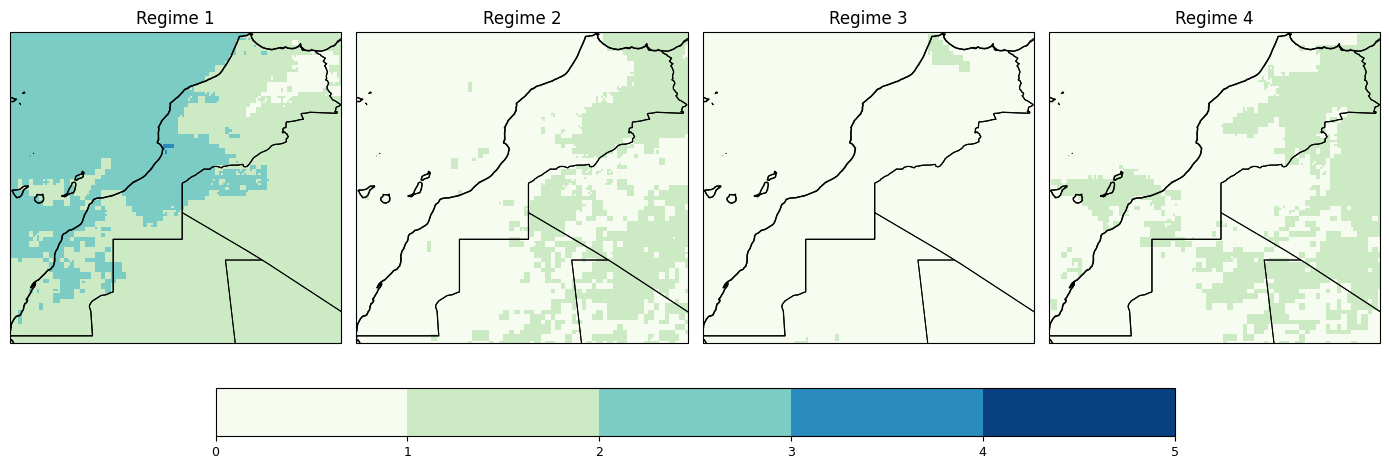

In [33]:
pr_qn95_ratio_full = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_all,
    labels           = labels_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_full,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = 'Odds ratio - 95th percentile precipitation (full period)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_full.png', dpi=150)
plt.show()


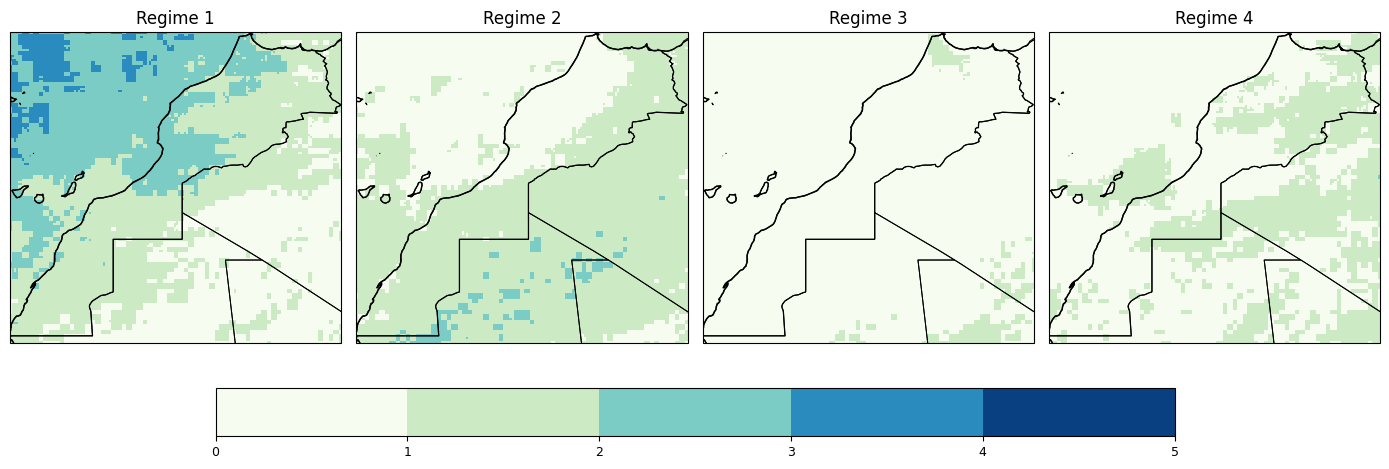

Holdout odds-ratio saved.


In [34]:
pr_qn95_ratio_holdout = cf.calculate_conditional_probability_change_label(
    threshold_matrix = threshold_qn95_holdout,
    labels           = labels_holdout_reordered,
    comparison       = 'ratio',
    shift_value      = 0)

cf.visualise_spatial_oddsratio(
    dataset_xarray = pr_qn95_ratio_holdout,
    unit           = '',
    color_scheme   = 'GnBu',
    vmin=0, vmax=5, steps=6,
    title          = 'Odds ratio - 95th percentile precipitation (holdout winters)',
    regime_names   = regime_names,
    borders        = True,
    projection     = ccrs.PlateCarree(central_longitude=0),
    col_number     = cluster_number)

plt.savefig(filepath + 'precip_odds_ratio_holdout.png', dpi=150)
plt.show()
print("Holdout odds-ratio saved.")


In [35]:
# CV BSS — out-of-fold predictions on training winters (leakage-free)
# Each training day is predicted by the fold whose training set did NOT include it.
bss_95_cv = sf.calculate_95pc_skill_score_probabilistic(
    cluster_number_z500        = cluster_number,
    z500_cluster_probabilities = soft_oof_aligned,
    pr_spatial                 = pr_spatial.isel(time=train_idx))

bss_cluster_cv = sf.calculate_cluster_skill_score_probabilistic(
    cluster_number_pr          = pr_cluster_number,
    cluster_number_z500        = cluster_number,
    pr_cluster_labels          = pr_labels_train,
    z500_cluster_probabilities = soft_oof_aligned)

print(f"CV BSS 95th pct  (out-of-fold training): {bss_95_cv:.4f}")
print(f"CV BSS cluster   (out-of-fold training): {bss_cluster_cv:.4f}")


Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...
CV BSS 95th pct  (out-of-fold training): 0.0111
CV BSS cluster   (out-of-fold training): 0.0078


In [36]:
import clustering_functions as cf
import skill_functions as sf
import pandas as pd
import numpy as np
import csv
import os

print("=" * 60)
print("  GOLD STANDARD METRICS (STANDARD VAE BASELINE)")
print("=" * 60)

# Holdout BSS
try:
    bss_95 = sf.calculate_95pc_skill_score_probabilistic(
        cluster_number_z500        = cluster_number,
        z500_cluster_probabilities = soft_holdout_aligned,
        pr_spatial                 = pr_spatial.isel(time=holdout_idx))
    bss_cluster = sf.calculate_cluster_skill_score_probabilistic(
        cluster_number_pr          = pr_cluster_number,
        cluster_number_z500        = cluster_number,
        pr_cluster_labels          = pr_labels_holdout,
        z500_cluster_probabilities = soft_holdout_aligned)
except Exception as e:
    print(f"Error calculating holdout BSS: {e}")
    bss_95 = np.nan
    bss_cluster = np.nan

# 1. BSS 95th Percentile
print("\n1. BSS 95th Percentile (Extreme Precipitation)")
try:
    print(f"   CV Score      (out-of-fold): {bss_95_cv:.4f}")
    print(f"   Holdout Score (unseen winters): {float(bss_95):.4f}")
except Exception as e:
    print(f"   (Error: {e})")

# 2. BSS Cluster
print("\n2. BSS Cluster (Regime Assignment)")
try:
    print(f"   CV Score      (out-of-fold): {bss_cluster_cv:.4f}")
    print(f"   Holdout Score (unseen winters): {float(bss_cluster):.4f}")
except Exception as e:
    print(f"   (Error: {e})")

# 3. Odds Ratios (Holdout)
print("\n3. Odds Ratio (Holdout)")
try:
    try:
        or_values = pr_qn95_ratio_holdout.values
    except AttributeError:
        or_values = pr_qn95_ratio_holdout
    or_flat  = or_values.reshape(cluster_number, -1)
    max_or   = np.nanmax(or_flat)
    mean_or  = np.mean(np.nanmax(or_flat, axis=1))
    print(f"   Max Odds Ratio:  {max_or:.2f}x")
    print(f"   Mean Odds Ratio: {mean_or:.2f}x")
except Exception as e:
    print(f"   (Error: {e})")

# 4. Regime Persistence (Holdout)
print("\n4. Regime Persistence")
try:
    persistence = cf.calculate_regime_persistence(c_holdout_aligned)
    for k, v in persistence.items():
        print(f"   Regime {int(k)+1}: {v:.1f} days")
    avg_pers = np.mean(list(persistence.values()))
    print(f"   Average across all regimes: {avg_pers:.1f} days")
except Exception as e:
    print(f"   (Error calculating persistence: {e})")

# 5. Silhouette Score (Training Latent Space)
print("\n5. Cluster Silhouette Score")
try:
    sil_score = cf.calculate_silhouette_score(z_mean_train, c_train)
    print(f"   Training Silhouette Score: {sil_score:.4f}")
except Exception as e:
    print(f"   (Error calculating Silhouette Score: {e})")
print("=" * 60)

# Save results for final comparison table
os.makedirs("results/standardized", exist_ok=True)
with open("results/standardized/vae_metrics.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Metric", "Value"])
    try: writer.writerow(["BSS 95 (CV out-of-fold)",     f"{bss_95_cv:.4f}"])
    except: pass
    try: writer.writerow(["BSS Cluster (CV out-of-fold)", f"{bss_cluster_cv:.4f}"])
    except: pass
    try: writer.writerow(["BSS 95 (Holdout)",             f"{float(bss_95):.4f}"])
    except: pass
    try: writer.writerow(["BSS Cluster (Holdout)",        f"{float(bss_cluster):.4f}"])
    except: pass
    try: writer.writerow(["Max Odds Ratio",               f"{max_or:.2f}"])
    except: pass
    try: writer.writerow(["Mean Odds Ratio",              f"{mean_or:.2f}"])
    except: pass
    try: writer.writerow(["Avg Persistence",              f"{avg_pers:.1f}"])
    except: pass
    try: writer.writerow(["Silhouette Score",             f"{sil_score:.4f}"])
    except: pass


  GOLD STANDARD METRICS (STANDARD VAE BASELINE)
Aggregating 3D precipitation data to 1D area-mean for 95pc skill score...

1. BSS 95th Percentile (Extreme Precipitation)
   CV Score      (out-of-fold): 0.0111
   Holdout Score (unseen winters): 0.0136

2. BSS Cluster (Regime Assignment)
   CV Score      (out-of-fold): 0.0078
   Holdout Score (unseen winters): 0.0240

3. Odds Ratio (Holdout)
   Max Odds Ratio:  3.57x
   Mean Odds Ratio: 2.50x

4. Regime Persistence
   Regime 1: 6.9 days
   Regime 2: 6.1 days
   Regime 3: 8.3 days
   Regime 4: 8.0 days
   Average across all regimes: 7.3 days

5. Cluster Silhouette Score
   Training Silhouette Score: 0.0883
